# Au [100] Verification: Multislice vs WPM vs Wave ODE

Thickness sweep for Au [100] comparing Fresnel, angular spectrum, WPM, and the second-order wave ODE. Publication plots use the full KG ODE result as the internal reference curve.

**Methods**: Fresnel (Paraxial), Angular Spectrum (Non-Paraxial), WPM, Second-Order Wave ODE

**Parameters**: Au FCC, a = 4.08 Å, 300 keV, 128×128×128 sampling, Weickenmeier-Kohl parametrization for the ODE reference, Lobato for Fresnel/Angular Spectrum/WPM.


In [40]:
%matplotlib widget

import os
from time import perf_counter

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".1"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from scipy.special import erfc as scipy_erfc
from tqdm.auto import tqdm

from wide_angle_propagation.propagation_methods import (
    electron_refractive_index,
    energy2wavelength,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_kg_ode_full,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
)
abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    Ny, Nx = psi_xy.shape
    C = np.fft.fft2(psi_xy) / (Nx * Ny)
    if use_fftshift:
        C = np.fft.fftshift(C)
        cy, cx = Ny // 2, Nx // 2
        return np.abs(C[cy + k, cx + h])
    else:
        return np.abs(C[k % Ny, h % Nx])

## Crystal setup and Weickenmeier-Kohl parametrization

Au FCC, a = 4.076 Å, 128 slices/cell, no thermal motion.
WK parametrization for forward KG methods to match paper.

In [41]:
from abtem.parametrizations import Parametrization

def weickenmeier_kohl_function(k2, parameters):
    A, B = parameters
    s2 = k2 / 4.0
    s2_expanded = s2[..., None]
    term = -np.expm1(-B * s2_expanded)
    sum_term = np.sum(A * term, axis=-1)
    with np.errstate(divide='ignore', invalid='ignore'):
        f_s = sum_term / s2
    limit_val = np.sum(A * B)
    f_s = np.where(s2 == 0, limit_val, f_s)
    return f_s * 47.87801

def weickenmeier_kohl_potential(r, parameters):
    A, B = parameters
    r = np.asarray(r, dtype=np.float64)
    result = np.zeros_like(r)
    for i in range(len(A)):
        result += A[i] * scipy_erfc(2 * np.pi * r / np.sqrt(B[i]))
    with np.errstate(divide='ignore', invalid='ignore'):
        V = 47.87801 * 4 * np.pi * result / r
    V = np.where(r < 1e-14, 1e30, V)
    return V

class WeickenmeierKohlParametrization(Parametrization):
    def __init__(self):
        super().__init__(parameters={})
        self._functions = {
            'elastic': weickenmeier_kohl_function,
            'projected_scattering_factor': weickenmeier_kohl_function,
            'potential': weickenmeier_kohl_potential,
        }

    def scaled_parameters(self, symbol, name):
        if "Au" not in symbol:
            raise NotImplementedError("Only Au is implemented.")
        Z = 79
        V = 0.4
        B = np.array([5.493e-01, 1.728e+00, 6.720e+00, 2.637e-02, 7.253e-02, 3.546e+01])
        factor = 0.02395 * Z
        a1_val = factor / (3 * (1 + V))
        A = np.array([a1_val, a1_val, a1_val, V * a1_val, V * a1_val, V * a1_val])
        return [A, B]

    def cutoff(self, symbol):
        return 20.0

# --- Crystal parameters ---
a_central = 4.076
n_slices_per_cell = 128
energy = 300e3
n_cells_range = range(0, 101)

atoms = bulk("Au", "fcc", a=a_central, cubic=True)
atoms.info['thermal_sigma'] = 0.0
atoms.arrays['thermal_sigma'] = np.zeros(len(atoms))

cell_thickness = atoms.get_cell()[2, 2]
slice_dz = cell_thickness / n_slices_per_cell

wk_param = WeickenmeierKohlParametrization()

# WK potential for KG methods
potential_wk = abtem.Potential(
    atoms, gpts=(128, 128), slice_thickness=slice_dz,
    projection="finite", parametrization=wk_param,
)
pot_array_wk = jnp.array(cupy.asnumpy(potential_wk.build(lazy=False).array / slice_dz))

# Lobato potential for MS/WPM methods
potential_lobato = abtem.Potential(
    atoms, gpts=(128, 128), slice_thickness=slice_dz,
    projection="finite", parametrization="lobato",
)
pot_array_lobato = jnp.array(cupy.asnumpy(potential_lobato.build(lazy=False).array / slice_dz))

# Plane wave and sampling
pw = abtem.PlaneWave(energy=energy)
pw.grid.match(potential_wk)
psi0 = jnp.array(cupy.asnumpy(pw.build(lazy=False).array))
sampling = (float(pw.grid.sampling[0]), float(pw.grid.sampling[1]))
wavelength = energy2wavelength(energy)

print(f"Au FCC, a = {a_central} Å, {n_slices_per_cell} slices/cell")
print(f"dz = {slice_dz:.4f} Å, energy = {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Grid: 128×128, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")

Au FCC, a = 4.076 Å, 128 slices/cell
dz = 0.0318 Å, energy = 300 keV, λ = 0.0197 Å
Grid: 128×128, sampling = (0.0318, 0.0318) Å


## Thickness sweep — Fresnel MS, Angular Spectrum MS, WPM

Run the three paraxial/semi-paraxial methods through 0–25 unit cells using Lobato parametrization.

In [42]:
fk = jnp.array(fresnel_propagation_kernel(128, 128, sampling, z=slice_dz, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(128, 128, sampling, z=slice_dz, energy=energy))

keys = ["ms_00", "ms_028", "as_00", "as_028", "wpm_00", "wpm_028"]
results = {k: [] for k in keys}
w_ms, w_as, w_wpm = psi0, psi0, psi0

for i in tqdm(range(len(n_cells_range)), desc="MS/WPM sweep"):
    if i > 0:
        w_ms, _, _ = simulate_fresnel_as(pot_array_lobato, w_ms, fk, slice_dz, energy)
        w_as, _, _ = simulate_fresnel_as(pot_array_lobato, w_as, ak, slice_dz, energy)
        w_wpm, _, _ = simulate_wpm(pot_array_lobato, w_wpm, slice_dz, energy, sampling)
        w_ms = jnp.array(w_ms)
        w_as = jnp.array(w_as)
        w_wpm = jnp.array(w_wpm)

    results["ms_00"].append(beam_amplitude_normalized(np.asarray(w_ms), 0, 0))
    results["ms_028"].append(beam_amplitude_normalized(np.asarray(w_ms), 0, 28))
    results["as_00"].append(beam_amplitude_normalized(np.asarray(w_as), 0, 0))
    results["as_028"].append(beam_amplitude_normalized(np.asarray(w_as), 0, 28))
    results["wpm_00"].append(beam_amplitude_normalized(np.asarray(w_wpm), 0, 0))
    results["wpm_028"].append(beam_amplitude_normalized(np.asarray(w_wpm), 0, 28))

beam_results = {k: np.array(v) for k, v in results.items()}
sweep_exit = {"ms": w_ms, "as": w_as, "wpm": w_wpm}
print(f"Sweep complete: {len(n_cells_range)} unit cells")

MS/WPM sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Sweep complete: 101 unit cells


## Second-Order Wave ODE thickness sweep (second-order, WK parametrization)

In [43]:
kg_ode_00, kg_ode_028 = [], []
w_kg = psi0
phi_kg = None

for i in tqdm(range(len(n_cells_range)), desc="Full KG ODE sweep"):
    if i > 0:
        w_kg, phi_kg, _, _ = simulate_kg_ode_full(
            pot_array_wk, w_kg, slice_dz, energy, sampling,
            initial_phi=phi_kg,
        )
        w_kg = jnp.array(w_kg)
    kg_ode_00.append(beam_amplitude_normalized(np.asarray(w_kg), 0, 0))
    kg_ode_028.append(beam_amplitude_normalized(np.asarray(w_kg), 0, 28))

kg_ode_00 = np.array(kg_ode_00)
kg_ode_028 = np.array(kg_ode_028)
print(f"KG ODE [0,0] final: {kg_ode_00[-1]:.6f}, [0,28] final: {kg_ode_028[-1]:.6f}")

Full KG ODE sweep:   0%|          | 0/101 [00:00<?, ?it/s]

KG ODE [0,0] final: 0.829076, [0,28] final: 0.034753


## Comparison plots - beam amplitudes vs Full KG ODE reference

Method colors, line styles, and markers are matched to the CBED notebook for visual consistency across figures. The paper-reference curves are intentionally omitted from this plotting view.

This cell produces one combined publication diagram: the full 0-100 unit-cell range on the top row and the 0-25 unit-cell view on the bottom row.

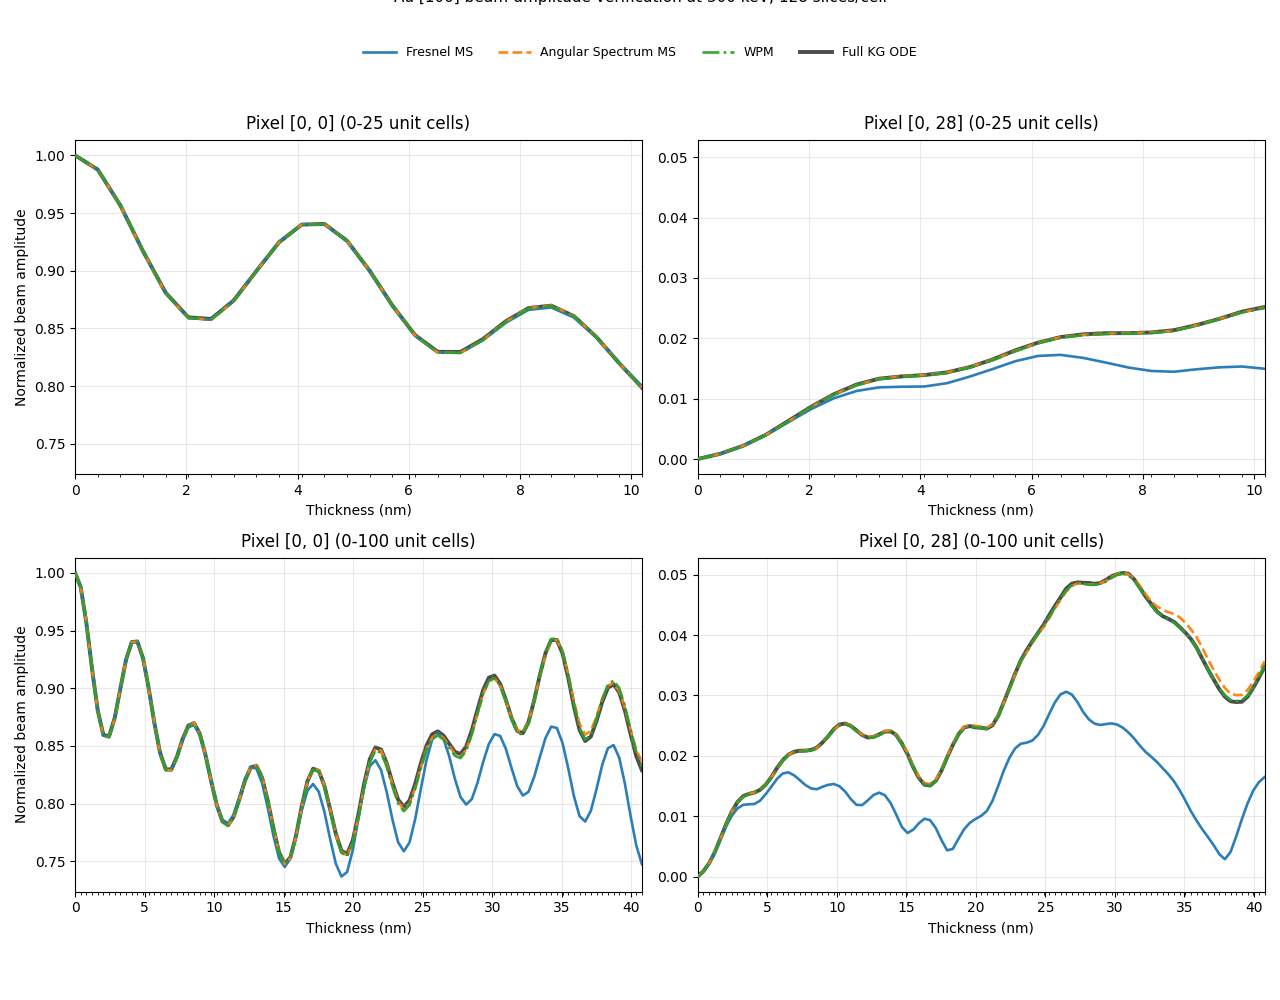

RMSE computed over the full simulated thickness range against Full KG ODE
Method                      [0,0] RMSE    [0,28] RMSE
-----------------------------------------------------
Fresnel MS                    0.037713       0.016791
Angular Spectrum MS           0.002074       0.000628
WPM                           0.002088       0.000140


In [44]:
from matplotlib.ticker import MultipleLocator

x = np.array(list(n_cells_range), dtype=float)
full_mask = np.ones_like(x, dtype=bool)
first25_mask = x <= 25

cell_thickness_nm = float(cell_thickness) * 0.1

def unit_cells_to_nm(values):
    return np.asarray(values, dtype=float) * cell_thickness_nm

method_colors = {
    "Fresnel MS": "C0",
    "Angular Spectrum MS": "C1",
    "WPM": "C2",
    "Full KG ODE": "0.10",
}
method_line_styles = {
    "Fresnel MS": "-",
    "Angular Spectrum MS": "--",
    "WPM": "-.",
    "Full KG ODE": "-",
}

methods_00 = {
    "Fresnel MS": beam_results["ms_00"],
    "Angular Spectrum MS": beam_results["as_00"],
    "WPM": beam_results["wpm_00"],
    "Full KG ODE": kg_ode_00,
}
methods_028 = {
    "Fresnel MS": beam_results["ms_028"],
    "Angular Spectrum MS": beam_results["as_028"],
    "WPM": beam_results["wpm_028"],
    "Full KG ODE": kg_ode_028,
}
display_names = {name: name for name in methods_00}
ordered_labels = ["Fresnel MS", "Angular Spectrum MS", "WPM", "Full KG ODE"]
plot_order = ["Full KG ODE", "Fresnel MS", "Angular Spectrum MS", "WPM"]

def curve_rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

fig, axes = plt.subplots(2, 2, figsize=(12.8, 10), sharey="col")
plot_specs = [
    (axes[0, 0], first25_mask, methods_00, "Pixel [0, 0]", "0-25 unit cells"),
    (axes[0, 1], first25_mask, methods_028, "Pixel [0, 28]", "0-25 unit cells"),
    (axes[1, 0], full_mask, methods_00, "Pixel [0, 0]", "0-100 unit cells"),
    (axes[1, 1], full_mask, methods_028, "Pixel [0, 28]", "0-100 unit cells"),
]
legend_handles = {}

for ax, x_mask, method_curves, panel_title, range_title in plot_specs:
    x_view = x[x_mask]
    x_view_nm = unit_cells_to_nm(x_view)
    for name in plot_order:
        y_view = np.asarray(method_curves[name])[x_mask]
        is_reference = name == "Full KG ODE"
        line, = ax.plot(
            x_view_nm,
            y_view,
            color=method_colors[name],
            linestyle=method_line_styles[name],
            linewidth=2.8 if is_reference else 1.9,
            alpha=0.78 if is_reference else 0.95,
            label=name,
            zorder=1 if is_reference else 3,
        )
        if name not in legend_handles:
            legend_handles[name] = line
    ax.set_title(f"{panel_title} ({range_title})", pad=8)
    ax.set_xlabel("Thickness (nm)")
    ax.grid(True, alpha=0.28)
    ax.set_xlim(x_view_nm.min(), x_view_nm.max())
    ax.xaxis.set_minor_locator(MultipleLocator(cell_thickness_nm))
    ax.tick_params(axis="x", which="minor", length=2.5)

axes[0, 0].set_ylabel("Normalized beam amplitude")
axes[1, 0].set_ylabel("Normalized beam amplitude")

fig.legend(
    [legend_handles[name] for name in ordered_labels],
    ordered_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=len(ordered_labels),
    frameon=False,
    fontsize=9,
    handlelength=2.6,
 )
fig.suptitle(
    f"Au [100] beam-amplitude verification at {energy/1e3:.0f} keV; "
    f"{n_slices_per_cell} slices/cell",
    fontsize=11,
    y=1.01,
 )
fig.tight_layout(rect=[0.0, 0.05, 1.0, 0.93])
plt.show()

print("RMSE computed over the full simulated thickness range against Full KG ODE")
print(f"{'Method':<25s} {'[0,0] RMSE':>12s} {'[0,28] RMSE':>14s}")
print("-" * 53)
for name in ordered_labels:
    if name == "Full KG ODE":
        continue
    r00 = curve_rmse(methods_00[name], methods_00["Full KG ODE"])
    r028 = curve_rmse(methods_028[name], methods_028["Full KG ODE"])
    print(f"{name:<25s} {r00:>12.6f} {r028:>14.6f}")


In [45]:
# Export combined figure for paper
from pathlib import Path

if "fig" not in globals():
    raise RuntimeError("Run the comparison-plot cell first so the combined figure exists.")

def resolve_paper_fig_dir():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / "Paper" / "figures"
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    raise FileNotFoundError("Could not locate Paper/figures from the current working directory")

paper_fig_dir = resolve_paper_fig_dir()
output_path = paper_fig_dir / "Au_pixel_amplitudes.pdf"
fig.savefig(output_path, format="pdf", bbox_inches="tight", dpi=300)
if not output_path.exists() or output_path.stat().st_size == 0:
    raise RuntimeError(f"Failed to write figure: {output_path}")

old_first25_path = paper_fig_dir / "Au_pixel_amplitudes_first25_unit_cells.pdf"
if old_first25_path.exists():
    old_first25_path.unlink()

print(f"Saved -> {output_path}")
if not old_first25_path.exists():
    print(f"Removed obsolete separate first-25 figure -> {old_first25_path}")


Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/Au_pixel_amplitudes.pdf
Removed obsolete separate first-25 figure -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/Au_pixel_amplitudes_first25_unit_cells.pdf


## Exit-wave and image-plane comparison at final thickness

The columns show exit-wave intensity and phase, followed by the intensity after a representative aberration-corrected 300 keV HRTEM objective-lens transfer function. A residual $C_s = 10$ µm and a 12 mrad objective aperture are used. The positive defocus is selected so the aberration phase increases monotonically from zero to $+\pi/2$ at the aperture edge; consequently, the phase CTF $\sin(\chi)$ remains positive throughout the transmitted band and does not invert contrast. A 2 nm focal-spread envelope is also applied. Display ranges are shared by column so differences between propagation methods remain visible.


In [ ]:
exit_wave_methods = [
    ("Full KG ODE", w_kg),
    ("WPM", sweep_exit["wpm"]),
    ("Angular Spectrum MS", sweep_exit["as"]),
    ("Fresnel MS", sweep_exit["ms"]),
]


def objective_lens_transfer_function(
    shape,
    sampling,
    wavelength,
    defocus_A,
    Cs_A,
    aperture_mrad,
    focal_spread_nm,
):
    """Representative objective-lens transfer function in FFT ordering."""
    ky = np.fft.fftfreq(shape[0], d=sampling[0])
    kx = np.fft.fftfreq(shape[1], d=sampling[1])
    kx, ky = np.meshgrid(kx, ky)
    spatial_frequency_squared = kx**2 + ky**2
    alpha = wavelength * np.sqrt(spatial_frequency_squared)

    chi = (
        np.pi * wavelength * defocus_A * spatial_frequency_squared
        + 0.5 * np.pi * Cs_A * wavelength**3 * spatial_frequency_squared**2
    )
    objective_aperture = alpha <= aperture_mrad * 1e-3

    focal_spread_A = focal_spread_nm * 10.0
    temporal_envelope = np.exp(
        -0.5
        * (np.pi * wavelength * focal_spread_A * spatial_frequency_squared) ** 2
    )
    return objective_aperture * temporal_envelope * np.exp(-1.0j * chi)


def global_phase_removed(wave):
    """Remove the physically arbitrary mean phase before phase visualization."""
    return wave * np.exp(-1.0j * np.angle(np.mean(wave)))


def shared_percentile_limits(arrays, lower=0.5, upper=99.5):
    values = np.concatenate([np.asarray(array).ravel() for array in arrays])
    vmin, vmax = np.percentile(values, [lower, upper])
    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0
    return float(vmin), float(vmax)


# Representative aberration-corrected 300 keV HRTEM settings. Choose the
# defocus so sin(chi) rises from 0 to +1 without a contrast reversal.
microscope_Cs_um = 10.0
microscope_Cs_A = microscope_Cs_um * 1e4
microscope_aperture_mrad = 12.0
microscope_aperture_rad = microscope_aperture_mrad * 1e-3
microscope_target_phase_rad = 0.5 * np.pi
microscope_defocus_A = (
    wavelength * microscope_target_phase_rad
    / (np.pi * microscope_aperture_rad**2)
    - 0.5 * microscope_Cs_A * microscope_aperture_rad**2
)
microscope_defocus_nm = microscope_defocus_A * 0.1
microscope_focal_spread_nm = 2.0

reference_shape = np.asarray(exit_wave_methods[0][1]).shape
objective_transfer = objective_lens_transfer_function(
    reference_shape,
    sampling,
    wavelength,
    microscope_defocus_A,
    microscope_Cs_A,
    microscope_aperture_mrad,
    microscope_focal_spread_nm,
)

exit_wave_intensities = {}
exit_wave_phases = {}
image_plane_intensities = {}

for name, wave in exit_wave_methods:
    wave = np.asarray(wave)
    exit_wave_intensities[name] = np.abs(wave) ** 2
    exit_wave_phases[name] = np.angle(global_phase_removed(wave))

    image_wave = np.fft.ifft2(np.fft.fft2(wave) * objective_transfer)
    image_plane_intensities[name] = np.abs(image_wave) ** 2

reference_image_intensity = image_plane_intensities["Full KG ODE"]
reference_image_rms = np.sqrt(np.mean(reference_image_intensity**2))
image_plane_nrmse = {
    name: np.sqrt(np.mean((values - reference_image_intensity) ** 2))
    / reference_image_rms
    for name, values in image_plane_intensities.items()
}

intensity_limits = shared_percentile_limits(exit_wave_intensities.values())
image_intensity_limits = shared_percentile_limits(image_plane_intensities.values())

extent_nm = [
    0.0,
    reference_shape[1] * sampling[1] * 0.1,
    reference_shape[0] * sampling[0] * 0.1,
    0.0,
]

n_methods = len(exit_wave_methods)
n_columns = 3
exit_fig = plt.figure(figsize=(11.8, 11.6), constrained_layout=True)
exit_grid = exit_fig.add_gridspec(
    n_methods,
    2 * n_columns,
    width_ratios=[1.0, 0.045, 1.0, 0.045, 1.0, 0.045],
    wspace=0.04,
)

exit_axes = np.empty((n_methods, n_columns), dtype=object)
reference_axis = None
for row in range(n_methods):
    for column in range(n_columns):
        axis_kwargs = {}
        if reference_axis is not None:
            axis_kwargs = {"sharex": reference_axis, "sharey": reference_axis}
        exit_axes[row, column] = exit_fig.add_subplot(
            exit_grid[row, 2 * column],
            **axis_kwargs,
        )
        if reference_axis is None:
            reference_axis = exit_axes[row, column]

colorbar_axes = [
    exit_fig.add_subplot(exit_grid[:, 2 * column + 1])
    for column in range(n_columns)
]

column_titles = [
    "Exit-wave intensity",
    "Exit-wave phase\n(global phase removed)",
    f"TEM image intensity\n(non-inverting defocus = {microscope_defocus_nm:+.1f} nm)",
]
for ax, title in zip(exit_axes[0], column_titles):
    ax.set_title(title, fontsize=10)

image_handles = [None] * n_columns
for row, (name, _) in enumerate(exit_wave_methods):
    values_by_column = [
        exit_wave_intensities[name],
        exit_wave_phases[name],
        image_plane_intensities[name],
    ]
    plot_options = [
        dict(cmap="gray", vmin=intensity_limits[0], vmax=intensity_limits[1]),
        dict(cmap="twilight", vmin=-np.pi, vmax=np.pi),
        dict(
            cmap="gray",
            vmin=image_intensity_limits[0],
            vmax=image_intensity_limits[1],
        ),
    ]

    for column, (ax, values, options) in enumerate(
        zip(exit_axes[row], values_by_column, plot_options)
    ):
        image_handles[column] = ax.imshow(values, extent=extent_nm, **options)
        ax.tick_params(labelsize=8)
        if row != n_methods - 1:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("x (nm)", fontsize=9)
        if column != 0:
            ax.tick_params(labelleft=False)

    exit_axes[row, 0].set_ylabel(f"{name}\ny (nm)", fontsize=9)
    if name == "Full KG ODE":
        comparison_text = "reference"
    else:
        comparison_text = f"NRMSE = {image_plane_nrmse[name]:.2e}"
    exit_axes[row, 2].text(
        0.97,
        0.04,
        comparison_text,
        transform=exit_axes[row, 2].transAxes,
        ha="right",
        va="bottom",
        fontsize=7.5,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.55, "edgecolor": "none", "pad": 1.5},
    )

colorbar_labels = ["Intensity", "Phase (rad)", "Intensity"]
for image_handle, colorbar_axis, label in zip(
    image_handles,
    colorbar_axes,
    colorbar_labels,
):
    colorbar = exit_fig.colorbar(image_handle, cax=colorbar_axis)
    colorbar.set_label(label, fontsize=8)
    colorbar.ax.tick_params(labelsize=7)

exit_fig.suptitle(
    f"Au [100] exit wave and HRTEM image after {x[-1]:.0f} unit cells "
    f"({unit_cells_to_nm([x[-1]])[0]:.2f} nm) at {energy/1e3:.0f} keV\n"
    f"$C_s$ = {microscope_Cs_um:.0f} $\\mu$m, defocus = "
    f"{microscope_defocus_nm:+.1f} nm, aperture = {microscope_aperture_mrad:.0f} mrad, "
    f"focal spread = {microscope_focal_spread_nm:.0f} nm",
    fontsize=11,
)
plt.show()

print("Representative aberration-corrected HRTEM transfer settings")
print(f"Residual Cs: {microscope_Cs_um:.1f} um")
print(f"Non-inverting defocus: {microscope_defocus_nm:+.2f} nm")
print(f"Objective aperture semi-angle: {microscope_aperture_mrad:.1f} mrad")
print(f"Phase at aperture edge: {microscope_target_phase_rad / np.pi:.2f} pi")
print(f"Focal spread: {microscope_focal_spread_nm:.1f} nm")
print("\nImage-plane intensity NRMSE against Full KG ODE")
for name, _ in exit_wave_methods:
    if name != "Full KG ODE":
        print(f"{name:<25s} {image_plane_nrmse[name]:.6e}")


In [47]:
# Export exit-wave comparison figure for paper
from pathlib import Path

if "exit_fig" not in globals():
    raise RuntimeError("Run the exit-wave comparison cell first so the figure exists.")

def resolve_paper_fig_dir():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / "Paper" / "figures"
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    raise FileNotFoundError("Could not locate Paper/figures from the current working directory")

paper_fig_dir = resolve_paper_fig_dir()
exit_output_path = paper_fig_dir / "Au_exit_wave_amplitudes.pdf"
exit_fig.savefig(exit_output_path, format="pdf", bbox_inches="tight", dpi=300)
if not exit_output_path.exists() or exit_output_path.stat().st_size == 0:
    raise RuntimeError(f"Failed to write figure: {exit_output_path}")

print(f"Saved -> {exit_output_path}")

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/Au_exit_wave_amplitudes.pdf


## RMSE summary vs Full KG ODE

In [48]:
print("% Paste into Paper/main.tex  ->  tab:rmse_verification")
print(r"\begin{tabular}{lcc}")
print(r"    \hline")
print(r"    \textbf{Method} & \textbf{RMSE $[0,0]$ vs KG ODE} & \textbf{RMSE $[0,28]$ vs KG ODE} \\")
print(r"    \hline")
for name in ordered_labels:
    if name == "Full KG ODE":
        continue
    r00 = curve_rmse(methods_00[name], methods_00["Full KG ODE"])
    r028 = curve_rmse(methods_028[name], methods_028["Full KG ODE"])
    latex_name = display_names.get(name, name).replace("&", r"\&")
    print(f"    {latex_name:<35s} & {r00:.4e} & {r028:.4e} \\\\")
print(r"    \hline")
print(r"\end{tabular}")

% Paste into Paper/main.tex  ->  tab:rmse_verification
\begin{tabular}{lcc}
    \hline
    \textbf{Method} & \textbf{RMSE $[0,0]$ vs KG ODE} & \textbf{RMSE $[0,28]$ vs KG ODE} \\
    \hline
    Fresnel MS                          & 3.7713e-02 & 1.6791e-02 \\
    Angular Spectrum MS                 & 2.0741e-03 & 6.2846e-04 \\
    WPM                                 & 2.0879e-03 & 1.4024e-04 \\
    \hline
\end{tabular}
